# Employee Attrition Prediction using Machine Learning

## Internship Project – Week 2

### Student Name: Pavithra P

### Objective

The objective of this project is to predict employee attrition using machine learning techniques and identify the factors that contribute to employee turnover. The insights generated from this project can help HR teams improve employee retention strategies and reduce workforce attrition.

## 1. Business Understanding

Employee attrition refers to employees leaving an organization voluntarily or involuntarily.

High attrition can result in:

- Increased hiring costs
- Training expenses
- Productivity loss
- Knowledge loss

This project aims to build a machine learning model that predicts whether an employee is likely to leave the organization based on demographic, job-related, and satisfaction-related factors.

Target Variable:

- Attrition = Yes (Employee Left)
- Attrition = No (Employee Stayed)

Business Goal:

To identify employees at risk of leaving and provide actionable recommendations to improve retention.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## 2. Data Loading & Exploration

In this section, the dataset is explored to understand its structure, dimensions, data types, target variable distribution, and overall data quality before preprocessing and model development.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


### Observation

The dataset contains 1,470 employee records and 35 columns. This dataset size is suitable for exploratory data analysis and machine learning classification.

In [5]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Observation

The dataset contains both numerical and categorical features. The target variable is Attrition, which indicates whether an employee left the company.

In [7]:
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols = df.select_dtypes(exclude='object').columns

print("Categorical Features:", len(categorical_cols))
print("Numerical Features:", len(numerical_cols))

print("\nCategorical Columns:")
print(categorical_cols.tolist())

Categorical Features: 9
Numerical Features: 26

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
attrition_rate = (
    df['Attrition']
    .value_counts(normalize=True)
    * 100
)

print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


### Attrition Analysis

Out of 1,470 employees, approximately 16.12% left the organization while 83.88% stayed.

The dataset is imbalanced because the number of employees who stayed is significantly larger than those who left.

Therefore, class imbalance handling will be considered during model training using class_weight='balanced'.

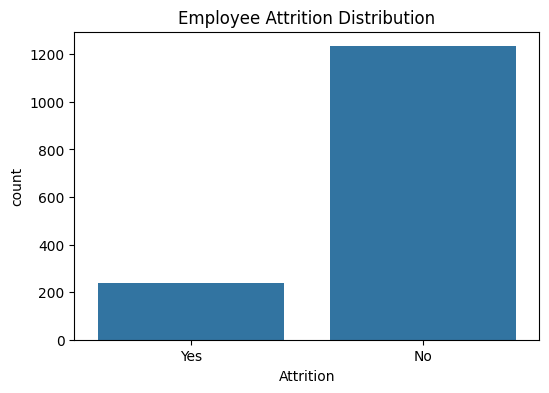

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title("Employee Attrition Distribution")
plt.show()

In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


### Missing Value Analysis

No missing values were found in the dataset.

Therefore, no imputation techniques are required before model training.

In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Duplicate Row Analysis

No duplicate employee records were identified in the dataset.

In [14]:
df.nunique().sort_values()

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [15]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print("Constant Columns:")
print(constant_cols)

Constant Columns:
['EmployeeCount', 'Over18', 'StandardHours']


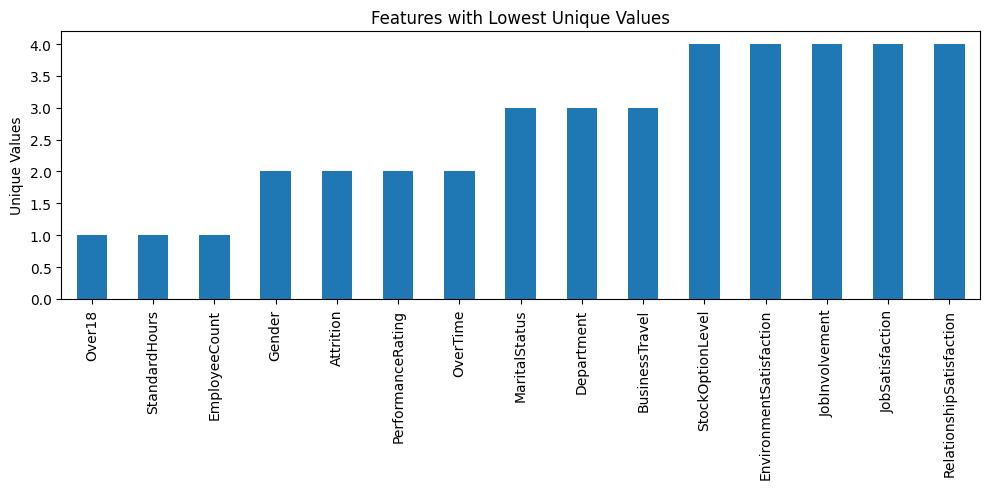

In [16]:
plt.figure(figsize=(10,5))

df.nunique().sort_values().head(15).plot(kind='bar')

plt.title("Features with Lowest Unique Values")
plt.ylabel("Unique Values")

plt.tight_layout()

plt.savefig(
    "charts/02_feature_uniqueness.png",
    bbox_inches="tight"
)

plt.show()

### Constant Feature Analysis

Three columns contain only one unique value:

- EmployeeCount
- Over18
- StandardHours

These variables provide no predictive information and will be removed during preprocessing.

In [17]:
audit_report = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.values,
    "Missing_Values": df.isnull().sum().values,
    "Unique_Values": df.nunique().values
})

audit_report.head()

,Feature,Data_Type,Missing_Values,Unique_Values
0,Age,int64,0,43
1,Attrition,object,0,2
2,BusinessTravel,object,0,3
3,DailyRate,int64,0,886
4,Department,object,0,3


In [18]:
audit_report.to_csv(
    "dataset_audit_report.csv",
    index=False
)

print("Audit report saved successfully!")

Audit report saved successfully!


## 4. Data Cleaning & Preprocessing

The dataset is prepared for machine learning by removing non-informative features, encoding the target variable, and preparing categorical variables for model training.

In [19]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df = df.drop(columns=drop_cols)

print("Updated Shape:", df.shape)

Updated Shape: (1470, 31)


### Feature Removal

The following columns were removed:

- EmployeeNumber
- EmployeeCount
- Over18
- StandardHours

These columns are either identifiers or constant-value features and therefore do not contribute to predictive performance.

In [20]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

In [21]:
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

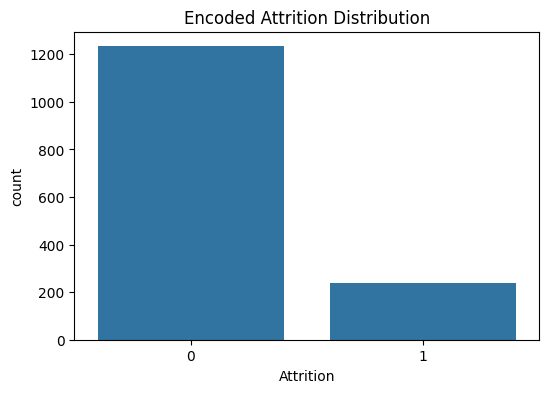

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Attrition',
    data=df
)

plt.title("Encoded Attrition Distribution")

plt.savefig(
    "charts/03_encoded_attrition.png",
    bbox_inches="tight"
)

plt.show()

## 5. Exploratory Data Analysis

The objective of this section is to identify patterns and business factors associated with employee attrition.

In [23]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition'],
    normalize='index'
) * 100

department_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


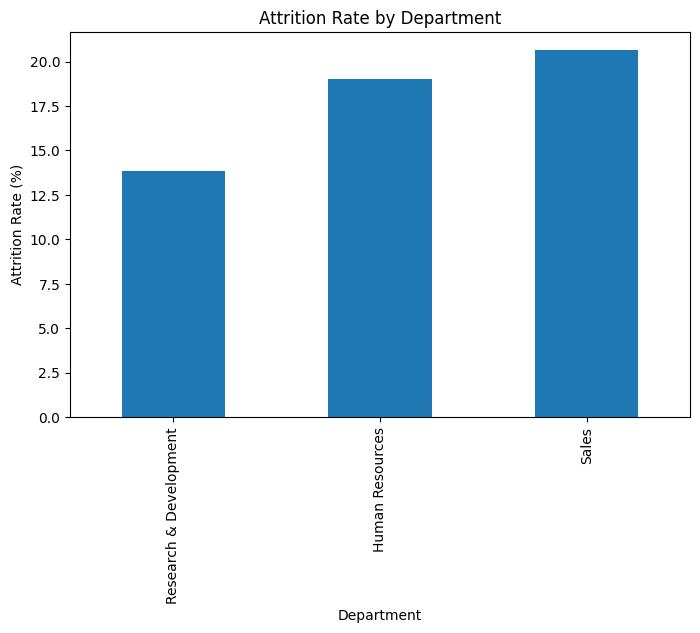

In [24]:
department_attrition[1].sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/04_department_attrition.png",
    bbox_inches="tight"
)

plt.show()

### Department Analysis

Sales department exhibits the highest attrition rate, while Research & Development shows the lowest.

This suggests that retention initiatives should prioritize departments experiencing higher turnover.

In [25]:
jobrole_attrition = pd.crosstab(
    df['JobRole'],
    df['Attrition'],
    normalize='index'
) * 100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


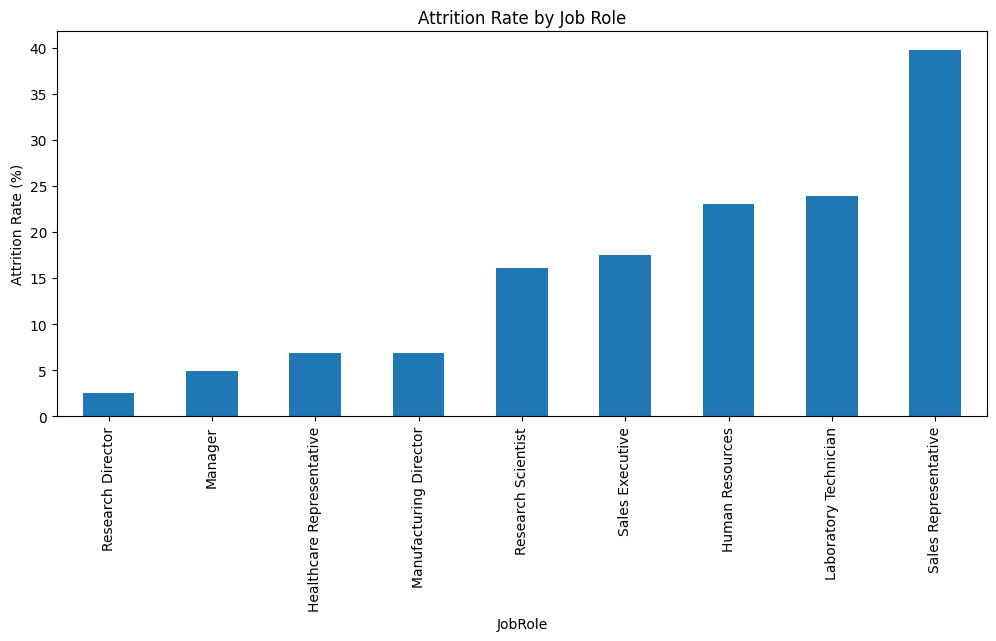

In [26]:
jobrole_attrition[1].sort_values().plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")

plt.savefig(
    "charts/05_jobrole_attrition.png",
    bbox_inches="tight"
)

plt.show()

### Observation

- Sales Representatives have the highest attrition rate (~40%).
- Laboratory Technicians and Human Resources employees also show relatively high attrition.
- Research Directors have the lowest attrition rate.
- Attrition varies significantly across job roles, indicating job role may be an important predictor.

### HR Insight

HR should prioritize retention strategies for Sales Representatives and Laboratory Technicians because these roles experience the greatest workforce loss.  

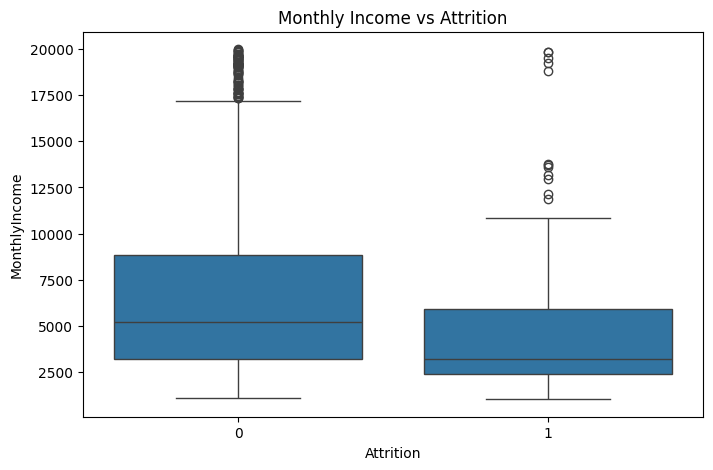

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title('Monthly Income vs Attrition')
plt.savefig('charts/06_income_attrition.png', bbox_inches='tight')
plt.show()

### Observation

- Employees who left the company generally have lower monthly income.
- Employees with higher salaries appear less likely to leave.

### HR Insight

Compensation may influence attrition, especially among lower-income employees. HR should review salary competitiveness for vulnerable employee groups.

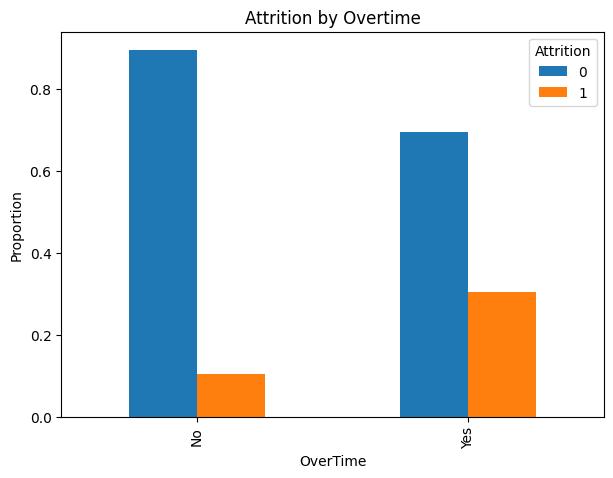

In [28]:
pd.crosstab(
    df['OverTime'],
    df['Attrition'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition by Overtime')
plt.ylabel('Proportion')

plt.savefig(
    'charts/07_overtime_attrition.png',
    bbox_inches='tight'
)

plt.show()

### Observation

- Employees working overtime show noticeably higher attrition.
- Employees not working overtime are more likely to remain with the company.

### HR Insight

Overtime may contribute to stress, burnout, and work-life imbalance. HR should monitor excessive overtime and ensure workload distribution is fair.

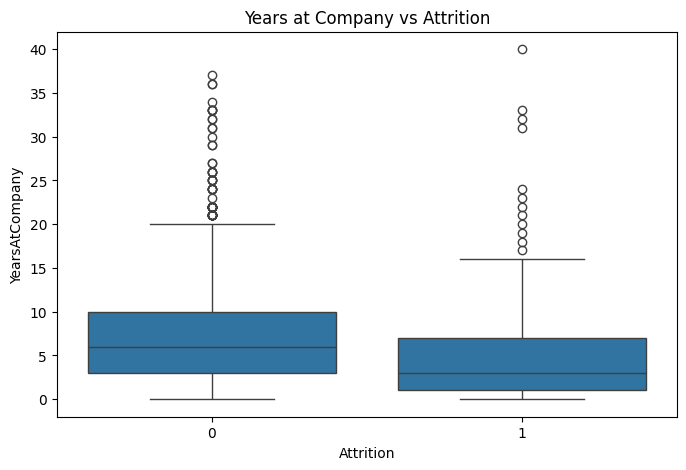

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title('Years at Company vs Attrition')

plt.savefig(
    'charts/08_years_company_attrition.png',
    bbox_inches='tight'
)

plt.show()

### Observation

- Employees who leave the organization generally have fewer years at the company.
- Attrition appears higher during the early stages of employment.

### HR Insight

Early-career retention programs, onboarding support, and mentorship initiatives may reduce turnover among newer employees.

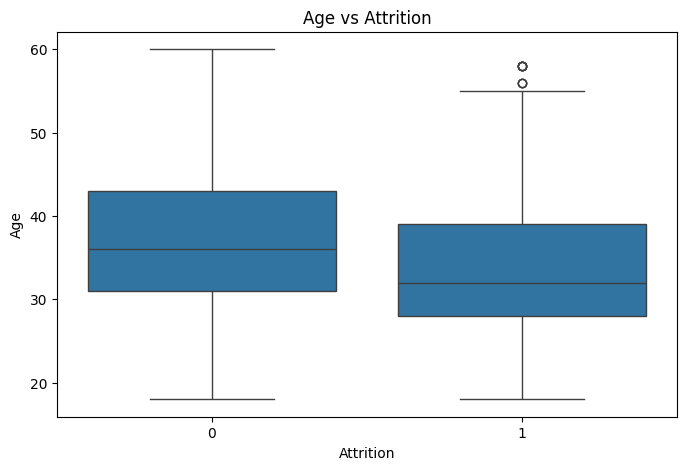

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='Age',
    data=df
)

plt.title('Age vs Attrition')

plt.savefig(
    'charts/09_age_attrition.png',
    bbox_inches='tight'
)

plt.show()

### Observation

- Younger employees appear more likely to leave the organization.
- Older employees tend to remain longer.

### HR Insight

Career growth opportunities and employee engagement initiatives may be especially important for younger employees.

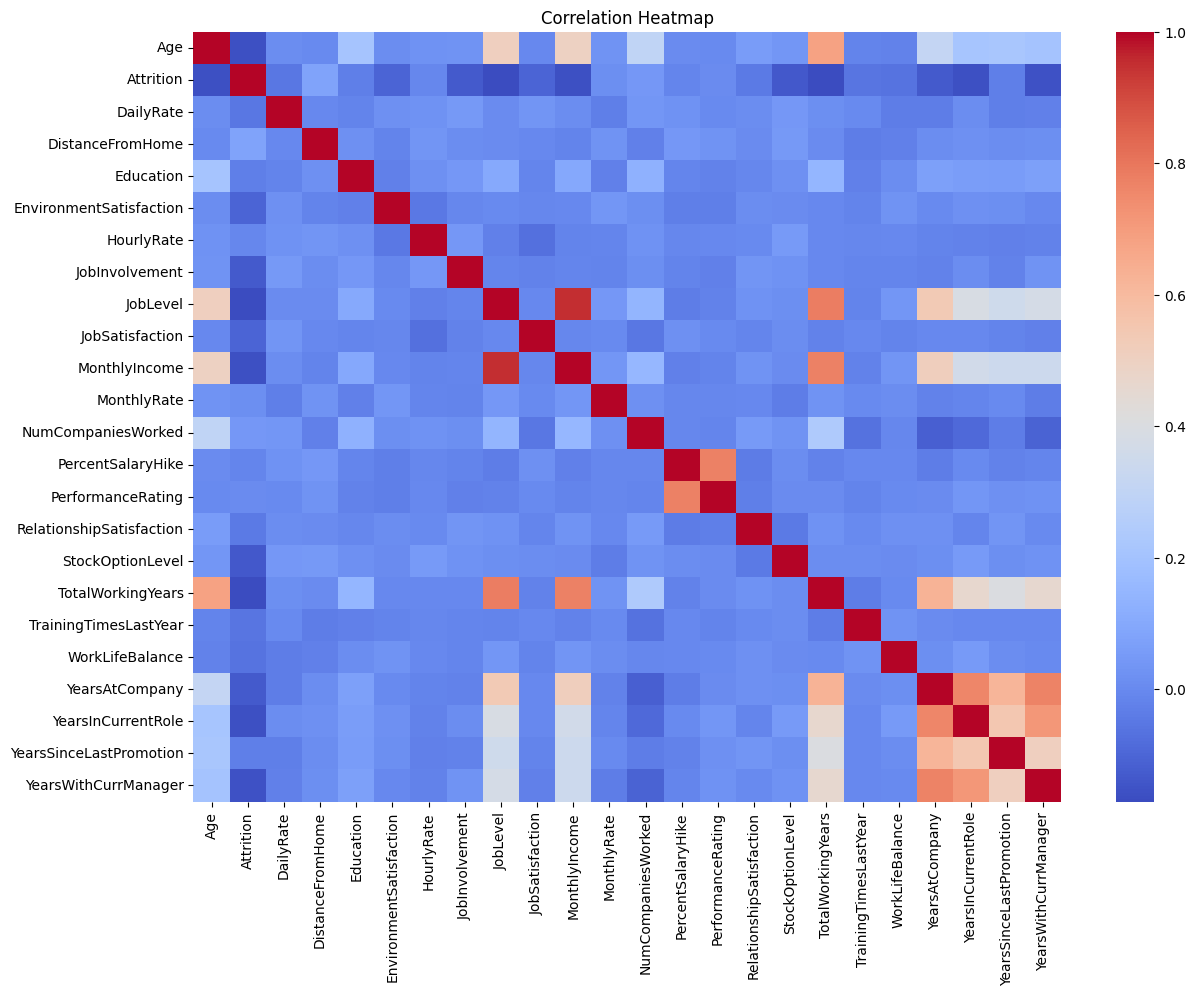

In [31]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')

plt.savefig(
    'charts/10_correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

### Observation

- Several numerical features show moderate relationships with attrition.
- No single variable completely explains employee turnover.
- Attrition appears to be influenced by multiple factors rather than a single cause.

### HR Insight

Employee attrition is a complex business problem that requires a combination of compensation, engagement, workload, and career development strategies.

# 6. Feature Encoding

In [32]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("Encoded Shape:", df_encoded.shape)

df_encoded.head()

Encoded Shape: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


All categorical variables have been converted into numerical format using One-Hot Encoding.

The dataset is now suitable for machine learning algorithms.

# 7. Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Attrition", axis=1)

y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (1176, 44)
Testing Features : (294, 44)
Training Labels  : (1176,)
Testing Labels   : (294,)


# 8. Feature Scaling

StandardScaler is applied to normalize feature values before training Logistic Regression. Tree-based models such as Random Forest and Gradient Boosting do not require feature scaling, but scaling is performed here for consistency.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (1176, 44)
Testing Data Shape  : (294, 44)


# 9. Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# 10. Logistic Regression Prediction

In [36]:
y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


# 11. Logistic Regression Evaluation

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_log)
precision = precision_score(y_test, y_pred_log)
recall = recall_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.7517
Precision: 0.3452
Recall   : 0.617
F1 Score : 0.4427


## Classification Report

In [38]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



## Confusion Matrix

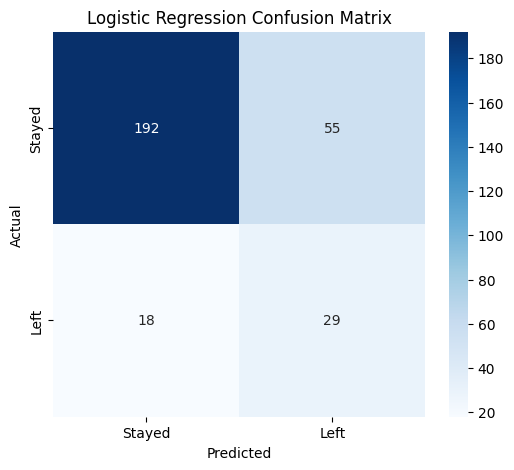

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig(
    "charts/11_logistic_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Observation

- The confusion matrix shows the number of correctly and incorrectly classified employees.
- A higher number on the diagonal indicates better model performance.

### HR Insight

The model can identify employees at risk of leaving and support HR teams in taking preventive retention actions.

# ROC Curve

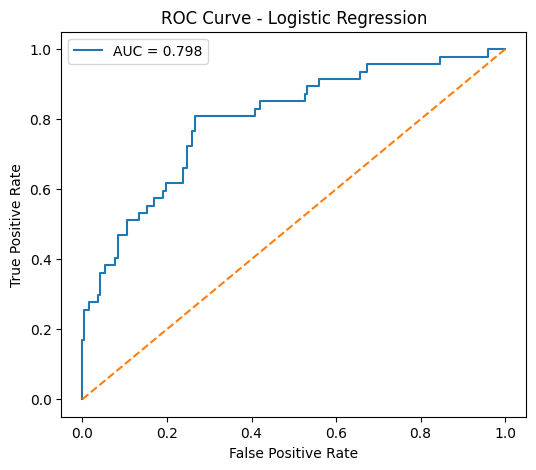

ROC-AUC Score: 0.7983


In [40]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob_log)

auc = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.savefig(
    "charts/12_logistic_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

print("ROC-AUC Score:", round(auc,4))

# 15. Random Forest Model

In [41]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## Random Forest Prediction

In [42]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("Predictions generated successfully!")

Predictions generated successfully!


## Random Forest Evaluation

In [43]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(accuracy_rf,4))
print("Precision:", round(precision_rf,4))
print("Recall   :", round(recall_rf,4))
print("F1 Score :", round(f1_rf,4))

Accuracy : 0.8367
Precision: 0.4444
Recall   : 0.0851
F1 Score : 0.1429


In [44]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



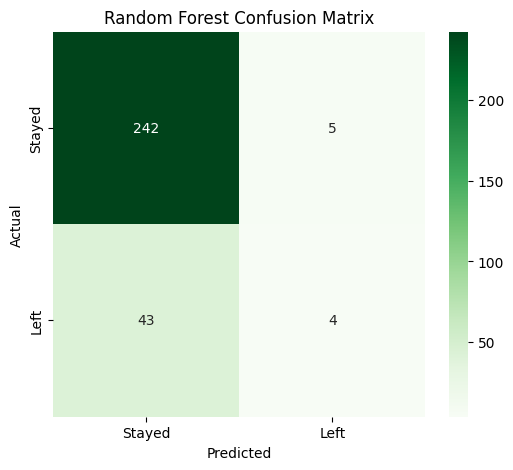

In [45]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "charts/13_random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

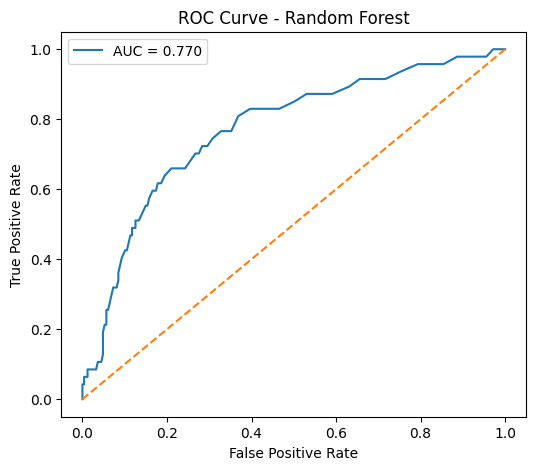

ROC-AUC Score: 0.7704


In [46]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.savefig(
    "charts/14_random_forest_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

print("ROC-AUC Score:", round(auc_rf,4))

# 21. Feature Importance

In [47]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
9          MonthlyIncome    0.074903
0                    Age    0.064226
1              DailyRate    0.054150
16     TotalWorkingYears    0.051777
19        YearsAtCompany    0.050795
10           MonthlyRate    0.046779
5             HourlyRate    0.045012
43          OverTime_Yes    0.043811
22  YearsWithCurrManager    0.041981
2       DistanceFromHome    0.041540


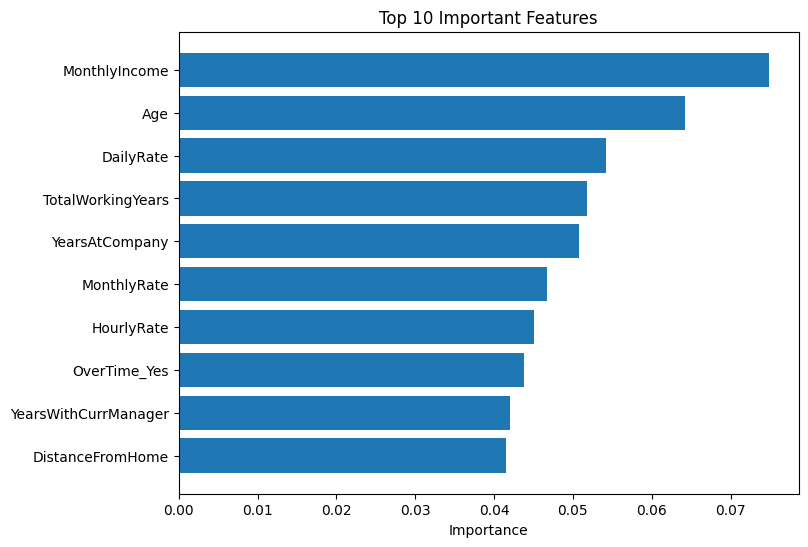

In [48]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.savefig(
    "charts/15_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

# 22. Model Comparison

In [49]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        auc_rf
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.751701,0.836735
1,Precision,0.345238,0.444444
2,Recall,0.617021,0.085106
3,F1 Score,0.442748,0.142857
4,ROC-AUC,0.798260,0.770394


# 23. Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds trees sequentially. Each new tree attempts to correct the errors made by the previous trees, often leading to strong predictive performance on structured datasets.

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


## 24. Gradient Boosting Predictions

In [51]:
y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)[:,1]

print("Predictions generated successfully!")

Predictions generated successfully!


## 25. Gradient Boosting Evaluation

In [52]:
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Accuracy :", round(accuracy_gb,4))
print("Precision:", round(precision_gb,4))
print("Recall   :", round(recall_gb,4))
print("F1 Score :", round(f1_gb,4))

Accuracy : 0.8503
Precision: 0.5882
Recall   : 0.2128
F1 Score : 0.3125


In [53]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



## 26. Gradient Boosting Confusion Matrix

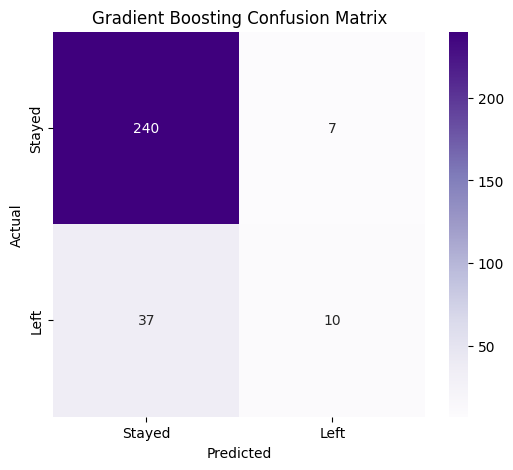

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Stayed","Left"],
    yticklabels=["Stayed","Left"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")

plt.savefig(
    "charts/16_gradient_boosting_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

### Observation

- Most employees who stayed are correctly classified.
- The model predicts attrition conservatively.
- False positives are low, but several employees who actually left are still missed.

## 27. Gradient Boosting ROC Curve

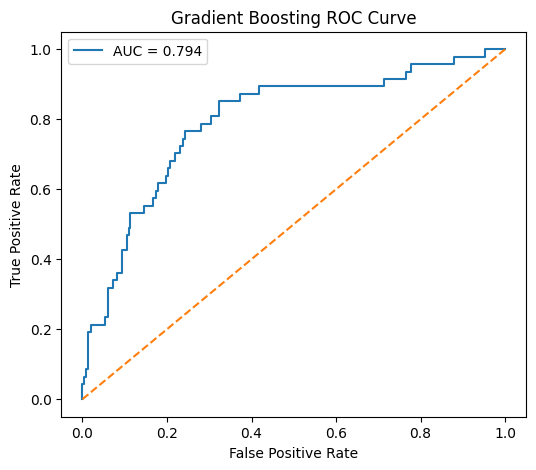

ROC-AUC Score: 0.7941


In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure(figsize=(6,5))

plt.plot(fpr_gb, tpr_gb, label=f"AUC = {auc_gb:.3f}")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")

plt.legend()

plt.savefig(
    "charts/17_gradient_boosting_roc_curve.png",
    bbox_inches="tight"
)

plt.show()

print("ROC-AUC Score:", round(auc_gb,4))

### Observation

- The ROC curve evaluates the model across all classification thresholds.
- A higher AUC indicates better discrimination between employees who stay and those who leave.
- This metric complements accuracy by measuring ranking performance rather than fixed-threshold predictions.

# 28. Model Comparison

In [56]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],

    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ],

    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        auc_rf
    ],

    "Gradient Boosting": [
        accuracy_gb,
        precision_gb,
        recall_gb,
        f1_gb,
        auc_gb
    ]
})

comparison

,Metric,Logistic Regression,Random Forest,Gradient Boosting
0,Accuracy,0.751701,0.836735,0.850340
1,Precision,0.345238,0.444444,0.588235
2,Recall,0.617021,0.085106,0.212766
3,F1 Score,0.442748,0.142857,0.312500
4,ROC-AUC,0.798260,0.770394,0.794125


### Observation

- Random Forest achieved the highest overall accuracy.
- Logistic Regression produced the highest recall, making it more effective at identifying employees who may leave.
- Gradient Boosting provided a balance between accuracy and precision, but its recall remained relatively low.
- For employee attrition prediction, recall is often more important than accuracy because failing to identify employees at risk of leaving can reduce the effectiveness of retention strategies.

# 29. HR Insights & Business Recommendations

### Key Findings

- Employees with lower monthly income are more likely to leave the organization.
- Employees working overtime show a higher risk of attrition.
- Years at the company and total working experience influence employee retention.
- Distance from home also contributes to employee turnover.
- Job involvement and work-life balance are important indicators of employee satisfaction.

### Business Recommendations

- Review salary structures for employees with lower income levels.
- Monitor overtime and promote healthier work-life balance.
- Conduct regular engagement and satisfaction surveys.
- Provide career growth opportunities for experienced employees.
- Develop targeted retention programs for employees identified as high risk.

# 30. Project Limitations

* The dataset used in this project is limited to historical employee records and may not represent all organizations or industries.
* The models rely only on the available features; factors such as employee motivation, company culture, and economic conditions are not included.
* Employee behavior and workplace trends may change over time, so the models should be retrained periodically using updated data.
* Although Random Forest and Gradient Boosting achieved higher accuracy, Logistic Regression provided better recall, which is often more valuable for identifying employees at risk of leaving.
* This project predicts the likelihood of employee attrition but cannot explain the exact reason why an individual employee decides to leave.

# 31. Executive Summary

This project developed a machine learning solution to predict employee attrition using HR analytics data. The workflow included data preprocessing, exploratory data analysis, feature encoding, feature scaling, model training, and performance evaluation.

Three machine learning models were implemented and compared:

* Logistic Regression
* Random Forest Classifier
* Gradient Boosting Classifier

Each model was evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, Confusion Matrix, and ROC Curve.

Among the evaluated models, Random Forest achieved the highest accuracy (83.67%), while Logistic Regression achieved the highest recall (61.70%), making it more effective for identifying employees who are likely to leave. Gradient Boosting provided a balanced performance but lower recall than Logistic Regression.

The project also identified important factors influencing employee attrition, including Monthly Income, Age, Total Working Years, Years at Company, Overtime, and Distance From Home.

Overall, this project demonstrates how machine learning can support HR departments in making proactive employee retention decisions and improving workforce planning.


# 32. Final Conclusion

This project successfully developed and evaluated machine learning models to predict employee attrition using HR analytics data. The complete workflow included data preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation.

Three classification models—Logistic Regression, Random Forest, and Gradient Boosting—were compared using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, Confusion Matrix, and ROC Curve.

The results showed that:

* **Random Forest** achieved the highest overall accuracy (83.67%).
* **Logistic Regression** achieved the highest recall (61.70%), making it more effective at identifying employees who are likely to leave.
* **Gradient Boosting** provided balanced performance but lower recall than Logistic Regression.

Feature importance analysis identified **Monthly Income, Age, Total Working Years, Years at Company, Overtime, and Distance From Home** as key factors influencing employee attrition.

Based on the project objectives, **Logistic Regression is recommended for HR attrition prediction**, as identifying employees at risk of leaving is generally more valuable than maximizing overall accuracy. These insights can help organizations implement proactive retention strategies, improve employee satisfaction, and support data-driven workforce planning.
